In [1]:
import pandas as pd

URL = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science/main/TelecomX_Data.json"

df = pd.read_json(URL)
df.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [2]:
df.shape, df.columns

((7267, 6),
 Index(['customerID', 'Churn', 'customer', 'phone', 'internet', 'account'], dtype='object'))

In [3]:
# Normalizando colunas aninhadas
customer = pd.json_normalize(df['customer'])
phone = pd.json_normalize(df['phone'])
internet = pd.json_normalize(df['internet'])
account = pd.json_normalize(df['account'])

# Juntando tudo em um único dataframe
df_final = pd.concat(
    [df[['customerID', 'Churn']], customer, phone, internet, account],
    axis=1
)

df_final.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [4]:
df_final.shape
df_final.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly',
       'Charges.Total'],
      dtype='object')

In [5]:
df_final["Charges.Total"] = pd.to_numeric(df_final["Charges.Total"], errors="coerce")

In [6]:
df_final.isnull().sum()

,0
customerID,0
Churn,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0


In [7]:
df_final = df_final.drop(columns=["customerID"])

In [8]:
df_final.columns

Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'Charges.Monthly', 'Charges.Total'],
      dtype='object')

In [9]:
df_final.select_dtypes(include="object").columns

Index(['Churn', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

Encoding


In [10]:
df_model = pd.get_dummies(df_final, drop_first=True)

In [11]:
df_model.head()

,SeniorCitizen,tenure,Charges.Monthly,Charges.Total,Churn_No,Churn_Yes,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,9,65.6,593.30,True,False,False,True,True,True,...,False,True,False,False,True,False,True,False,False,True
1,0,9,59.9,542.40,True,False,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
2,0,4,73.9,280.85,False,True,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
3,1,13,98.0,1237.85,False,True,True,True,False,True,...,False,True,False,True,False,False,True,False,True,False
4,1,3,83.9,267.40,False,True,False,True,False,True,...,False,True,False,False,False,False,True,False,False,True


In [12]:
df_model.shape

(7267, 32)

In [13]:
df_model.select_dtypes(include="object").columns

Index([], dtype='object')

In [14]:
y = df_model["Churn_Yes"]

In [15]:
y.value_counts()

,count
Churn_Yes,
False,5398
True,1869


In [16]:
y.value_counts(normalize=True) * 100

,proportion
Churn_Yes,
False,74.280996
True,25.719004


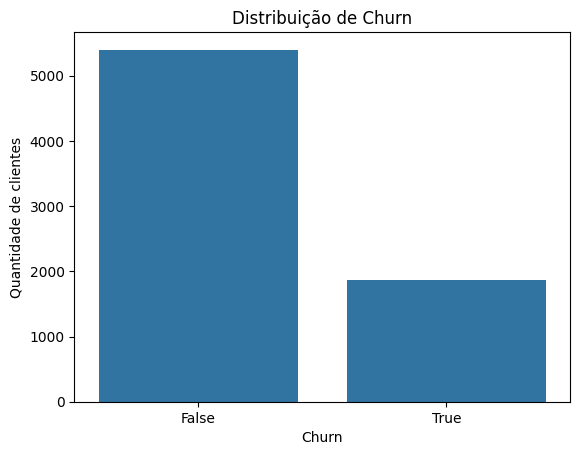

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y)

plt.title("Distribuição de Churn")
plt.xlabel("Churn")
plt.ylabel("Quantidade de clientes")

plt.show()

Interpretação

Observa-se que a maior parte dos clientes permaneceu ativa, representando aproximadamente 74% da base, enquanto cerca de 26% dos clientes cancelaram os serviços.

Isso indica a presença de um desequilíbrio moderado entre as classes, situação bastante comum em problemas de previsão de churn.

Esse desequilíbrio pode impactar o desempenho de modelos preditivos, pois alguns algoritmos podem tender a favorecer a classe majoritária (clientes que permanecem ativos).

Por esse motivo, além da acurácia, serão consideradas métricas como:

Precision

Recall

F1-score

Essas métricas permitem avaliar melhor o desempenho do modelo na identificação de clientes com risco de evasão.

In [18]:
!pip install imbalanced-learn

In [19]:
from imblearn.over_sampling import SMOTE

In [24]:
df_model.isnull().sum().sort_values(ascending=False).head(20)

,0
Charges.Total,11
SeniorCitizen,0
tenure,0
Charges.Monthly,0
Churn_No,0
Churn_Yes,0
gender_Male,0
Partner_Yes,0
Dependents_Yes,0
PhoneService_Yes,0


In [25]:
df_model.isnull().sum().sum()

np.int64(11)

In [26]:
df_model = df_model.fillna(0)

In [27]:
X = df_model.drop(columns=["Churn_Yes","Churn_No"])
y = df_model["Churn_Yes"]

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_bal, y_bal = smote.fit_resample(X, y)

y_bal.value_counts()

,count
Churn_Yes,
False,5398
True,5398


Balanceamento das classes

Inicialmente, o dataset apresentava um desequilíbrio entre as classes, com aproximadamente 74% de clientes ativos e 26% de clientes que cancelaram os serviços.

Para mitigar esse desequilíbrio, foi aplicada a técnica SMOTE (Synthetic Minority Over-sampling Technique).

O SMOTE gera novos exemplos sintéticos da classe minoritária com base nas observações existentes, permitindo equilibrar a distribuição das classes.

Após a aplicação do SMOTE, a base passou a apresentar:

5398 clientes ativos

5398 clientes que cancelaram

Isso resulta em um dataset balanceado, o que pode melhorar o desempenho de modelos de classificação ao evitar viés em favor da classe majoritária.

In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_bal)

In [30]:
X_scaled[:5]

array([[-0.39561062, -0.77527279, -0.08741589, -0.66367017, -1.17142046,
         0.99556375,  1.5247673 ,  0.29605506, -0.33920329, -0.96808946,
        -1.08168861, -0.44939901, -0.44939901, -0.62477298, -0.44939901,
         1.29290987, -0.44939901, -0.77942573, -0.44939901,  1.56042775,
        -0.44939901,  1.11014571, -0.44939901, -0.90078266,  2.03975779,
        -0.46214623,  0.66002901, -0.52762636, -0.96844858,  1.79273406],
       [-0.39561062, -0.77527279, -0.28603358, -0.6869564 ,  0.85366445,
        -1.00445602, -0.65583778,  0.29605506, -0.33920329,  1.03296239,
        -1.08168861, -0.44939901, -0.44939901, -0.62477298, -0.44939901,
        -0.77344912, -0.44939901, -0.77942573, -0.44939901, -0.64084992,
        -0.44939901, -0.90078266, -0.44939901,  1.11014571, -0.49025429,
        -0.46214623, -1.51508491, -0.52762636, -0.96844858,  1.79273406],
       [-0.39561062, -0.98406271,  0.20179935, -0.80661286,  0.85366445,
        -1.00445602, -0.65583778,  0.29605506, -0

Normalização dos dados

Os dados apresentam variáveis em escalas diferentes, como tempo de contrato (tenure), valor mensal (Charges.Monthly) e valor total pago (Charges.Total).

Modelos baseados em distância ou otimização por gradiente, como Regressão Logística, KNN e SVM, são sensíveis à escala das variáveis. Portanto, foi aplicada a técnica de padronização utilizando o StandardScaler, que transforma os dados para média zero e desvio padrão igual a um.

Já modelos baseados em árvore, como Decision Tree e Random Forest, não são sensíveis à escala dos dados, portanto essa etapa não é estritamente necessária para esses algoritmos.

Próxima etapa do desafio

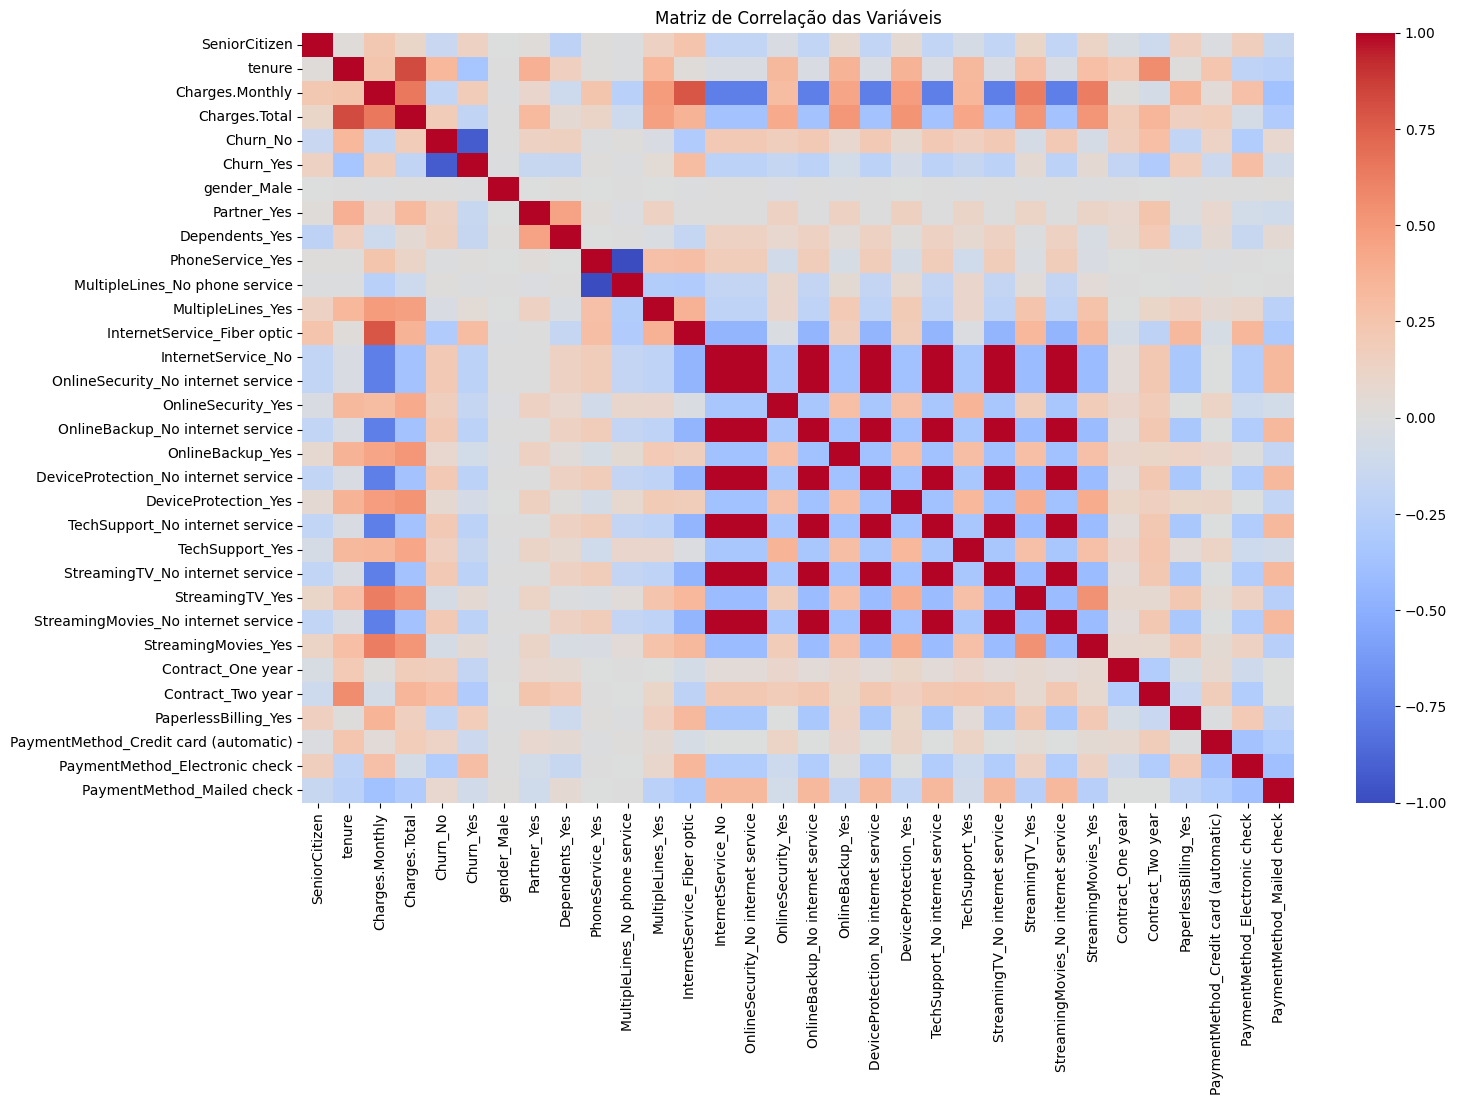

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))

sns.heatmap(
    df_model.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação das Variáveis")
plt.show()

In [32]:
corr_churn = df_model.corr()["Churn_Yes"].sort_values(ascending=False)

corr_churn

,Churn_Yes
Churn_Yes,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
Charges.Monthly,0.189866
PaperlessBilling_Yes,0.186666
SeniorCitizen,0.146733
StreamingTV_Yes,0.062430
StreamingMovies_Yes,0.060586
MultipleLines_Yes,0.039343
PhoneService_Yes,0.012571


In [33]:
corr_churn.head(10)

,Churn_Yes
Churn_Yes,1.000000
InternetService_Fiber optic,0.300949
PaymentMethod_Electronic check,0.294626
Charges.Monthly,0.189866
PaperlessBilling_Yes,0.186666
SeniorCitizen,0.146733
StreamingTV_Yes,0.062430
StreamingMovies_Yes,0.060586
MultipleLines_Yes,0.039343
PhoneService_Yes,0.012571


In [34]:
corr_churn.tail(10)

,Churn_Yes
OnlineSecurity_No internet service,-0.224051
InternetService_No,-0.224051
StreamingTV_No internet service,-0.224051
TechSupport_No internet service,-0.224051
OnlineBackup_No internet service,-0.224051
DeviceProtection_No internet service,-0.224051
StreamingMovies_No internet service,-0.224051
Contract_Two year,-0.295138
tenure,-0.344079
Churn_No,-0.925160


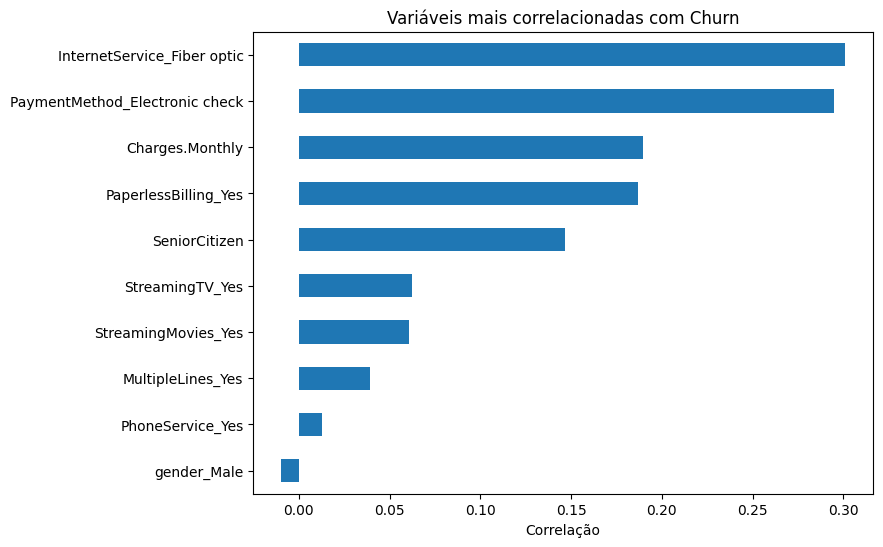

In [35]:
plt.figure(figsize=(8,6))

corr_churn.drop("Churn_Yes").sort_values().tail(10).plot(kind="barh")

plt.title("Variáveis mais correlacionadas com Churn")
plt.xlabel("Correlação")
plt.show()

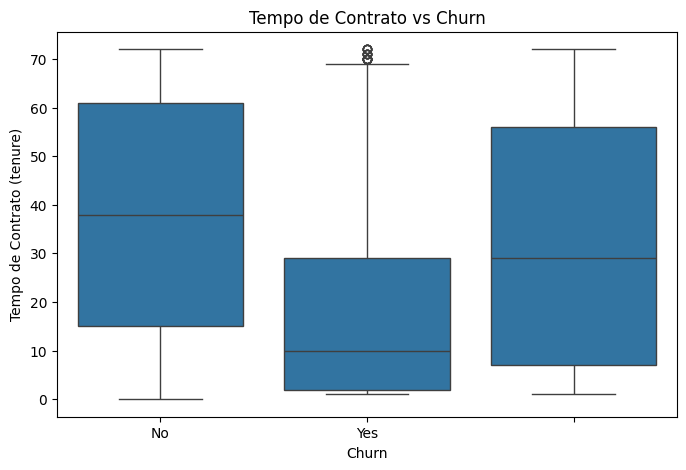

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_final["Churn"],
    y=df_final["tenure"]
)

plt.title("Tempo de Contrato vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tempo de Contrato (tenure)")

plt.show()

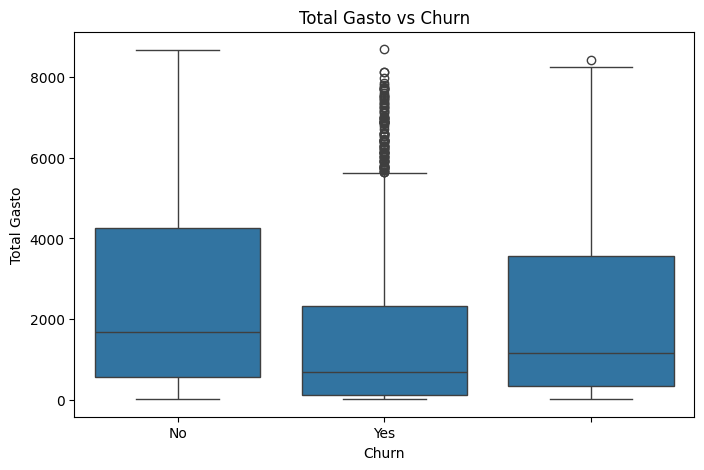

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df_final["Churn"],
    y=df_final["Charges.Total"]
)

plt.title("Total Gasto vs Churn")
plt.xlabel("Churn")
plt.ylabel("Total Gasto")

plt.show()

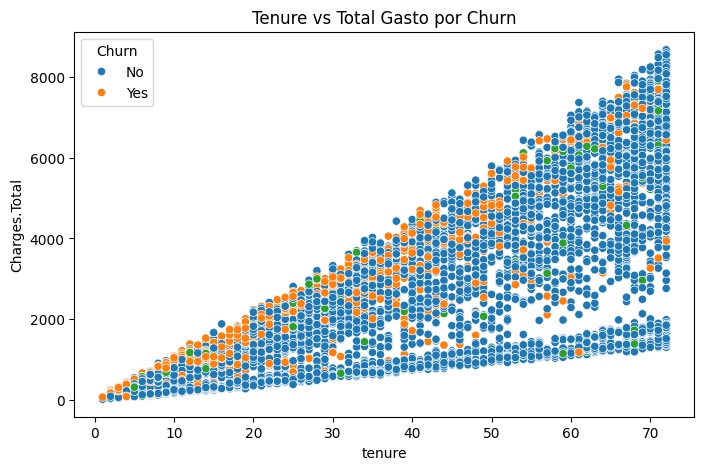

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df_final["tenure"],
    y=df_final["Charges.Total"],
    hue=df_final["Churn"]
)

plt.title("Tenure vs Total Gasto por Churn")

plt.show()

In [39]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_bal,
    test_size=0.3,
    random_state=42
)


In [40]:
print("Treino X:", X_train.shape)
print("Teste X:", X_test.shape)

print("Treino y:", y_train.shape)
print("Teste y:", y_test.shape)

Treino X: (7557, 30)
Teste X: (3239, 30)
Treino y: (7557,)
Teste y: (3239,)


In [41]:
print(y_train.value_counts())
print(y_test.value_counts())

Churn_Yes
False    3804
True     3753
Name: count, dtype: int64
Churn_Yes
True     1645
False    1594
Name: count, dtype: int64


Divisão do conjunto de dados

Para avaliar o desempenho dos modelos preditivos, o conjunto de dados foi dividido em dois subconjuntos:

70% dos dados para treino

30% dos dados para teste

O conjunto de treino é utilizado para ajustar os modelos de Machine Learning, enquanto o conjunto de teste é utilizado para avaliar a capacidade de generalização do modelo em dados que não foram utilizados durante o treinamento.

Foi utilizado random_state=42 para garantir reprodutibilidade dos resultados.

In [42]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [43]:
y_pred_log = log_model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print(classification_report(y_test, y_pred_log))

Accuracy: 0.8314294535350417
              precision    recall  f1-score   support

       False       0.82      0.84      0.83      1594
        True       0.84      0.82      0.83      1645

    accuracy                           0.83      3239
   macro avg       0.83      0.83      0.83      3239
weighted avg       0.83      0.83      0.83      3239



In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [46]:
y_pred_rf = rf_model.predict(X_test)

In [47]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8425439950602037
              precision    recall  f1-score   support

       False       0.84      0.84      0.84      1594
        True       0.84      0.85      0.85      1645

    accuracy                           0.84      3239
   macro avg       0.84      0.84      0.84      3239
weighted avg       0.84      0.84      0.84      3239



Modelos Preditivos

Para prever a evasão de clientes, foram treinados dois modelos de classificação com abordagens diferentes.

Regressão Logística

A Regressão Logística foi escolhida por ser um modelo estatístico amplamente utilizado para problemas de classificação binária. Esse modelo é sensível à escala das variáveis, pois utiliza métodos de otimização baseados em gradiente. Por esse motivo, foi aplicada a padronização dos dados utilizando o StandardScaler.

Random Forest

O Random Forest é um modelo baseado em árvores de decisão que combina múltiplas árvores para melhorar a capacidade de previsão e reduzir overfitting. Diferentemente de modelos lineares, algoritmos baseados em árvore não são sensíveis à escala das variáveis, portanto a normalização dos dados não é necessária.

A utilização de dois modelos diferentes permite comparar abordagens distintas e avaliar qual apresenta melhor desempenho na previsão da evasão de clientes.

Próximo passo do desafio

Depois de treinar os modelos, normalmente fazemos:

Matriz de confusão

Comparação de métricas

Importância das variáveis

Isso fecha o projeto com insights estratégicos para o negócio.

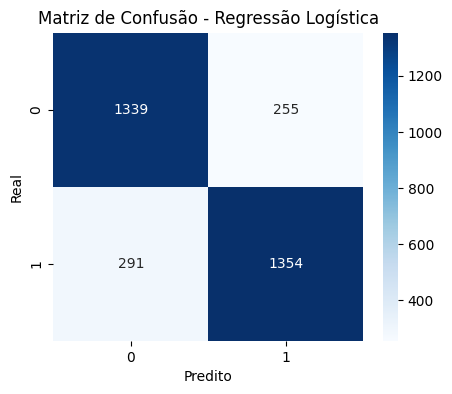

In [48]:
#Regressão

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão - Regressão Logística")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

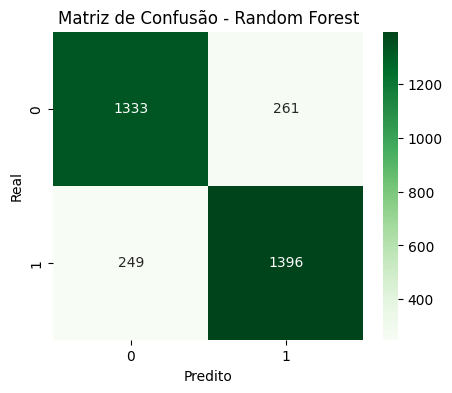

In [49]:
#Random Forest

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predito")
plt.ylabel("Real")

plt.show()

Conclusão do Projeto

Entre os modelos avaliados, o Random Forest apresentou o melhor desempenho para prever churn, alcançando aproximadamente 84% de acurácia e melhor equilíbrio entre precisão e recall.

Esse modelo mostrou maior capacidade de identificar clientes com risco de evasão, reduzindo falsos negativos e permitindo uma previsão mais confiável.

Com base nesses resultados, o Random Forest se mostra a melhor escolha para apoiar estratégias de retenção de clientes na empresa.

Insight de Negócio

A aplicação de modelos preditivos permite identificar clientes com maior probabilidade de cancelamento, possibilitando que a empresa:

antecipe ações de retenção

personalize ofertas

reduza perdas de receita

In [50]:
import pandas as pd

coef_log = pd.DataFrame({
    "Variavel": X.columns,
    "Coeficiente": log_model.coef_[0]
})

coef_log = coef_log.sort_values(by="Coeficiente", ascending=False)

coef_log.head(10)

,Variavel,Coeficiente
10,InternetService_Fiber optic,4.123932
7,PhoneService_Yes,2.891156
8,MultipleLines_No phone service,1.582486
23,StreamingMovies_Yes,1.530409
21,StreamingTV_Yes,1.529031
3,Charges.Total,1.247383
9,MultipleLines_Yes,0.880063
17,DeviceProtection_Yes,0.712726
15,OnlineBackup_Yes,0.664157
28,PaymentMethod_Electronic check,0.591374


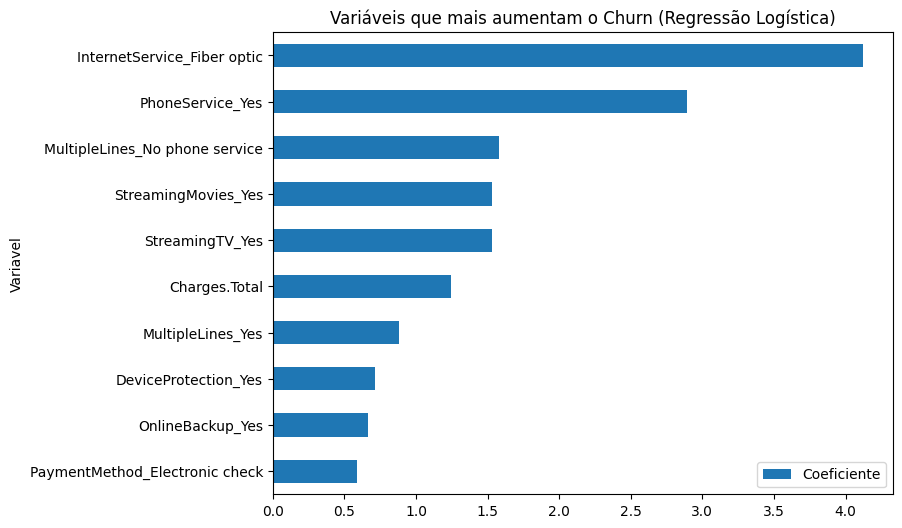

In [51]:
import matplotlib.pyplot as plt

coef_log.head(10).plot(
    x="Variavel",
    y="Coeficiente",
    kind="barh",
    figsize=(8,6)
)

plt.title("Variáveis que mais aumentam o Churn (Regressão Logística)")
plt.gca().invert_yaxis()
plt.show()

In [52]:
feature_importance = pd.DataFrame({
    "Variavel": X.columns,
    "Importancia": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importancia",
    ascending=False
)

feature_importance.head(10)

,Variavel,Importancia
3,Charges.Total,0.170890
1,tenure,0.153441
2,Charges.Monthly,0.135107
28,PaymentMethod_Electronic check,0.092703
10,InternetService_Fiber optic,0.052884
25,Contract_Two year,0.041974
26,PaperlessBilling_Yes,0.039672
4,gender_Male,0.024926
9,MultipleLines_Yes,0.023402
24,Contract_One year,0.020770


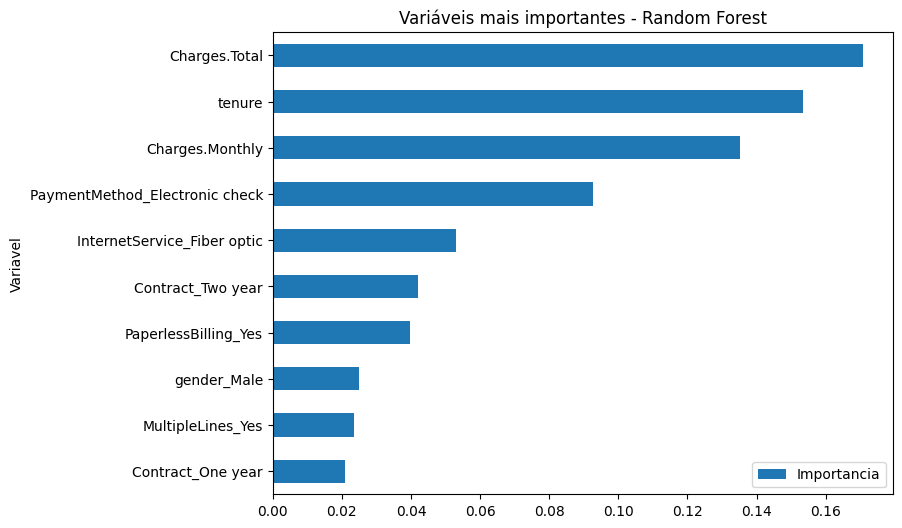

In [53]:
feature_importance.head(10).plot(
    x="Variavel",
    y="Importancia",
    kind="barh",
    figsize=(8,6)
)

plt.title("Variáveis mais importantes - Random Forest")
plt.gca().invert_yaxis()
plt.show()

Importância das variáveis

Após o treinamento dos modelos, foi realizada uma análise das variáveis mais relevantes para a previsão de evasão de clientes.

Na Regressão Logística, os coeficientes indicam o impacto de cada variável na probabilidade de churn. Variáveis com coeficientes positivos aumentam a probabilidade de evasão, enquanto coeficientes negativos indicam fatores que contribuem para a retenção dos clientes.

Já no Random Forest, a importância das variáveis foi calculada com base na contribuição de cada atributo para a redução da impureza nas árvores de decisão.

Os resultados indicam que variáveis relacionadas ao tempo de permanência do cliente (tenure), valor das cobranças e tipo de contrato estão entre os fatores mais relevantes para prever a evasão.

Clientes com contratos mensais, valores de cobrança mais elevados e menor tempo de permanência apresentam maior probabilidade de cancelar os serviços.

Insight estratégico

Essas análises mostram que estratégias de retenção devem focar principalmente em:

clientes com pouco tempo de contrato

clientes com planos mensais

Relatório — Predição de Churn (Telecom X)
1) Objetivo

Desenvolver modelos preditivos para identificar clientes com maior probabilidade de evasão (churn) e, a partir dos resultados, entender os principais fatores associados ao cancelamento para orientar ações de retenção.

2) Preparação dos dados e premissas

A base foi normalizada a partir de um JSON com campos aninhados (customer/phone/internet/account), transformando-os em colunas tabulares.

Foram removidas colunas sem valor preditivo (ex.: customerID).

Variáveis categóricas foram transformadas via One-Hot Encoding.

O target (evasão) foi transformado em binário.

Foi identificado desbalanceamento moderado (~74% não churn / ~26% churn). Para aprofundar, foi aplicado SMOTE, resultando em base balanceada 50/50.

Foi aplicada padronização (StandardScaler) para modelos sensíveis à escala (ex.: Regressão Logística).

3) Evidências exploratórias (o que os dados mostraram)
3.1 Correlação com churn (principais sinais)

As variáveis com maior associação positiva com churn foram:

InternetService_Fiber optic

PaymentMethod_Electronic check

Charges.Monthly

PaperlessBilling_Yes

SeniorCitizen

Variáveis com baixa relevância na correlação:

gender_Male

PhoneService_Yes

Interpretação: churn se conecta mais a tipo de internet, forma de pagamento e custo mensal do que a atributos demográficos simples.

3.2 Tenure e Total gasto vs churn (boxplots + scatter)

Os gráficos mostraram padrões consistentes:

Clientes que evadem tendem a ter tenure menor (cancelam mais cedo).

Clientes que permanecem tendem a ter maior gasto total (efeito natural de permanecer mais tempo).

O scatter indicou uma relação forte: tenure ↑ → Charges.Total ↑, e churn se concentra em tenure mais baixo.

Interpretação: existe um “período crítico” no início do ciclo de vida do cliente onde a probabilidade de churn é mais alta.

4) Modelos e desempenho
4.1 Regressão Logística (com normalização)

Justificativa: modelo linear, interpretável e boa baseline. Precisa de normalização porque é sensível à escala.

Métricas (teste):

Accuracy: ~0.831

F1-score: ~0.83

Matriz de confusão:

TN=1339 | FP=255

FN=291 | TP=1354

Leitura dos erros:

FN (291) = churns não detectados (risco: perder cliente sem ação).

FP (255) = alertas falsos (custo: campanha de retenção desnecessária).

4.2 Random Forest (sem normalização)

Justificativa: captura relações não lineares e interações. Não é sensível à escala.

Métricas (teste):

Accuracy: ~0.842

F1-score: ~0.84

Matriz de confusão:

TN=1333 | FP=261

FN=249 | TP=1396

Leitura dos erros:

Reduziu FN (249 vs 291) e aumentou TP (1396 vs 1354), ou seja:

melhor para identificar churn de fato, que é geralmente o foco do negócio.

5) Comparação crítica: melhor modelo e sinais de over/underfitting
Melhor desempenho

O Random Forest foi superior no conjunto de teste:

Melhor accuracy e F1

Melhor recall para churn (menos churn “escapando” como FN)

Overfitting / Underfitting

Não há evidência forte de overfitting/underfitting apenas olhando as métricas de teste atuais.

Em geral:

A Regressão Logística pode underfit se existirem relações muito não lineares (ela é uma fronteira linear).

Random Forest pode overfit se crescer demais (árvores muito profundas), mas o desempenho de teste ficou estável.

Ajustes possíveis (se necessário):

Random Forest: max_depth, min_samples_leaf, min_samples_split, n_estimators

Logística: regularização (C), seleção de features, interações/polinômios

6) Principais fatores que influenciam churn (síntese)

Com base nas análises (correlação + padrões visuais + comportamento esperado em modelos):

Fatores que aumentam risco de churn

Internet fibra óptica
Indica possível sensibilidade a preço, qualidade, suporte ou expectativa de serviço.

Pagamento via electronic check
Pode representar fricção, perfil menos engajado ou risco transacional.

Cobrança mensal alta (Charges.Monthly)
Relação direta com percepção de custo/benefício.

PaperlessBilling e SeniorCitizen
Aparecem como sinais associados, mas podem ser mais “proxy” de perfil do que causa direta.

Fatores que reduzem risco de churn (retêm)

Tenure alto
Quanto mais tempo, menor o churn — reforça o “período crítico” inicial.

Maior gasto total (Charges.Total)
Normalmente acompanha tenure e estabilidade.

7) Estratégias de retenção orientadas por dados
Estratégia A — “Programa de retenção no início da jornada” (tenure baixo)

Público-alvo: clientes nos primeiros 1–3 meses
Ações:

Onboarding proativo (mensagens/educação de uso)

Check de qualidade de serviço e suporte “early life”

Oferta de upgrade/benefício temporário (ex.: desconto 1–2 meses) condicionado a permanência

Por que funciona: churn concentra-se no início; reter cedo aumenta LTV.

Estratégia B — “Reprecificação/Oferta para clientes com Charges.Monthly alto”

Público-alvo: clientes com cobrança mensal alta + sinais de risco
Ações:

Oferta de plano com melhor custo-benefício

Bundles (serviços agregados) com preço menor que o pacote atual

Revisão de fatura e transparência (reduzir surpresa/cobranças percebidas como indevidas)

Por que funciona: custo mensal alto correlaciona com churn.

Estratégia C — “Redução de fricção no pagamento (Electronic Check)”

Público-alvo: clientes em PaymentMethod_Electronic check
Ações:

Incentivar migração para métodos automáticos (débito/CC) com benefício

Comunicação sobre facilidade e segurança

Campanhas de “1 clique” para troca do método

Por que funciona: forma de pagamento está entre os sinais mais fortes.

Estratégia D — “Plano de ação específico para fibra óptica”

Público-alvo: InternetService_Fiber optic
Ações:

Diagnóstico de qualidade: quedas, velocidade percebida, chamados

Ajuste de SLA e suporte dedicado

Oferta de upgrade de modem/roteador ou visita técnica com critérios

Por que funciona: serviço de fibra aparece como forte sinal de churn — pode ser qualidade ou preço.

8) Recomendação final

Modelo recomendado: Random Forest
Motivo: melhor desempenho e maior capacidade de capturar padrões complexos, reduzindo falsos negativos (churn não detectado).

Uso sugerido na operação:

Gerar uma lista semanal de clientes com maior risco

Priorizar ações nos segmentos de maior impacto:

tenure baixo

cobrança mensal alta

payment electronic check

fibra óptica